# Multiple Linear Regression — Complete Guide

Linear regression is one of the first models you learn in machine learning. The idea is simple: **draw the best straight-line relationship between some inputs and an output you want to predict.**

This notebook builds that idea up step by step:

- **Multiple Linear Regression** — predicting a number from *several* inputs at once (e.g. predicting a house price from its size, number of bedrooms, and age).
- **Performance Metrics (MSE, MAE, RMSE, R², Adjusted R²)** — ways to measure how good our predictions are.
- **Overfitting vs Underfitting** — the two ways a model can go wrong.
- **OLS (Ordinary Least Squares)** — a formula that finds the best-fit line in one shot, no trial-and-error needed.

Everything is shown with worked examples, real datasets, and plenty of pictures using `matplotlib`, `seaborn`, and `numpy`. You don't need any prior ML knowledge — just a little comfort with algebra.

## Table of Contents
1. Multiple Linear Regression — The Intuition & Equation
2. Writing It Compactly: Matrix Form
3. How the Model Learns: Cost Function & Gradient Descent
4. Solving It in One Shot: OLS (the Normal Equation)
5. Measuring Error: MAE, MSE, RMSE
6. Measuring Fit: R² and Adjusted R²
7. Overfitting and Underfitting
8. The Bias-Variance Tradeoff
9. **Full Worked Example — Predicting House Prices**
10. Checking Our Work Against scikit-learn

## Setup — Import Libraries

In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D
from matplotlib import cm
from scipy import stats

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['axes.titlesize'] = 14

np.random.seed(42)

## 1. Multiple Linear Regression — The Intuition & Equation

**Simple linear regression** uses just *one* input (X) to predict the output (Y). It's the classic "line of best fit":
$$\hat{y} = \theta_0 + \theta_1 x$$

Here $\hat{y}$ (read "y-hat") is our *predicted* value. The $\theta$ symbols (the Greek letter "theta") are just numbers the model has to figure out.

**Multiple linear regression** does the same thing, but with **many inputs** (x₁, x₂, ..., xₙ) instead of one:

$$\hat{y} = \theta_0 + \theta_1 x_1 + \theta_2 x_2 + \theta_3 x_3 + \dots + \theta_n x_n$$

Read this as: *take each input, multiply it by its own weight, add them all up, plus a starting value.* That's the whole model.

- **Features** (the x's) are the inputs you already know — like a house's size and age.
- **Target** (Y) is the thing you're trying to predict — like the house's price.
- Each **θ (theta)** is a *weight* the model learns. A bigger weight means that input matters more.
- **θ₀** is the **intercept** (also called the *bias*) — the baseline value of Y when every input is zero.

### Real-World Examples

| Target (Y) — what we predict | Features (X's) — what we already know |
|---|---|
| House price | size, bedrooms, age, location |
| Salary | experience, education, city, skills |
| Car price | mileage, brand, engine size, age |
| Student marks | study hours, attendance, previous score |
| Sales | ad spend, price, season, competitors |

### What Do the Weights (θ) Actually Mean?

Each weight θᵢ answers one question: **"If I increase this one input by 1 unit and keep everything else the same, how much does the prediction change?"**

The "keeping everything else the same" part is important — it's what lets us isolate the effect of a single feature.

Example — a house price model:
$$\text{Price} = 50{,}000 + 200 \times \text{Size} + 10{,}000 \times \text{Bedrooms} - 500 \times \text{Age}$$

- Each extra square foot adds ₹200 (with bedrooms and age unchanged).
- Each extra bedroom adds ₹10,000.
- Each extra year of age *subtracts* ₹500 — the minus sign means "older = cheaper."
- The ₹50,000 intercept is just the math's starting point. A "0 sqft, 0 bedroom" house isn't real, so don't read too much into the intercept on its own.

C:\Users\EBBQT\AppData\Local\Temp\ipykernel_14196\3624977194.py:31: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\EBBQT\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\EBBQT\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


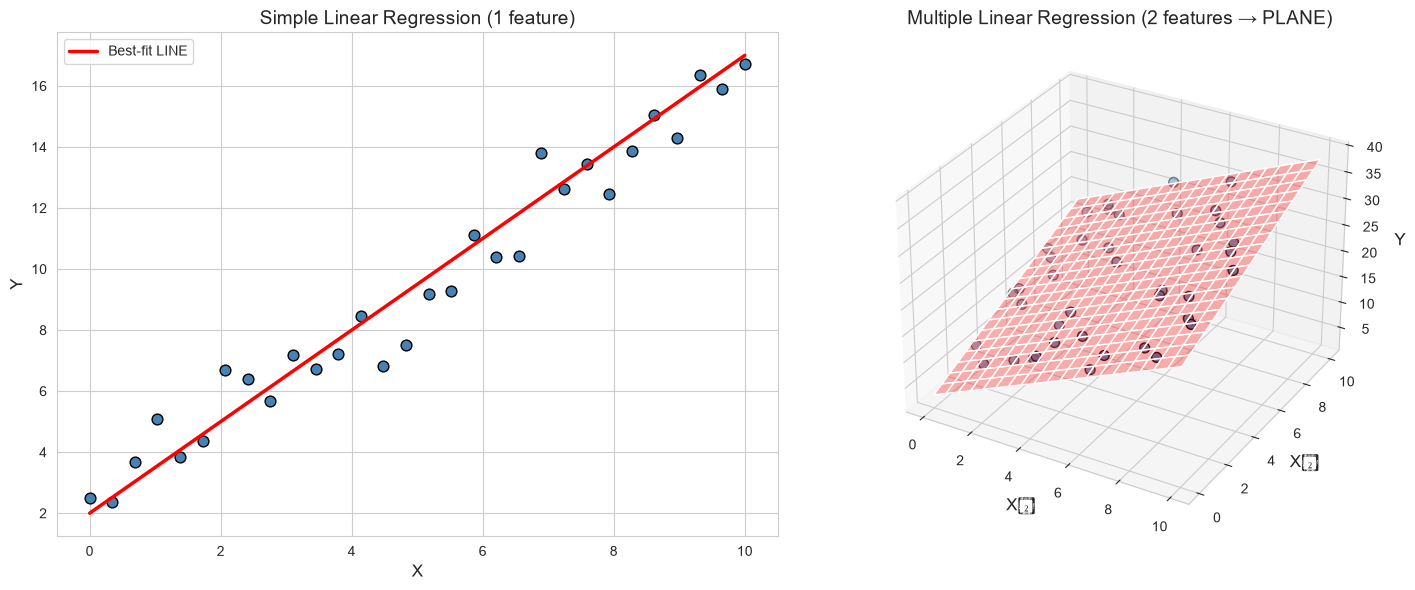

- 1 feature  → best fit is a LINE  (2D plot)
- 2 features → best fit is a PLANE (3D plot)
- n features → best fit is a HYPERPLANE (can't visualize, but same math)


In [20]:
# Visualize: 1 feature (line), 2 features (plane), 3+ features (impossible to plot directly)
fig = plt.figure(figsize=(15, 6))

# Simple LR — line
ax1 = fig.add_subplot(1, 2, 1)
x_ex = np.linspace(0, 10, 30)
y_ex = 2 + 1.5 * x_ex + np.random.normal(0, 1, 30)
ax1.scatter(x_ex, y_ex, s=60, color='steelblue', edgecolor='black')
ax1.plot(x_ex, 2 + 1.5 * x_ex, 'r-', linewidth=2.5, label='Best-fit LINE')
ax1.set_title('Simple Linear Regression (1 feature)')
ax1.set_xlabel('X')
ax1.set_ylabel('Y')
ax1.legend()

# Multiple LR — plane
ax2 = fig.add_subplot(1, 2, 2, projection='3d')
np.random.seed(1)
x1 = np.random.uniform(0, 10, 40)
x2 = np.random.uniform(0, 10, 40)
y2 = 3 + 2*x1 + 1.5*x2 + np.random.normal(0, 2, 40)

ax2.scatter(x1, x2, y2, s=50, color='steelblue', edgecolor='black')
X1_grid, X2_grid = np.meshgrid(np.linspace(0, 10, 20), np.linspace(0, 10, 20))
Y_plane = 3 + 2*X1_grid + 1.5*X2_grid
ax2.plot_surface(X1_grid, X2_grid, Y_plane, alpha=0.3, color='red')
ax2.set_xlabel('X₁')
ax2.set_ylabel('X₂')
ax2.set_zlabel('Y')
ax2.set_title('Multiple Linear Regression (2 features → PLANE)')

plt.tight_layout()
plt.show()

print('- 1 feature  → best fit is a LINE  (2D plot)')
print('- 2 features → best fit is a PLANE (3D plot)')
print('- n features → best fit is a HYPERPLANE (can\'t visualize, but same math)')

## 2. Writing It Compactly: Matrix Form

Writing out `θ₀ + θ₁x₁ + θ₂x₂ + ...` for every single house gets tedious fast. Mathematicians use **matrices** (grids of numbers) as a shorthand to do all those multiplications and additions at once. The entire model collapses into one tiny expression:

$$\hat{\mathbf{y}} = \mathbf{X} \boldsymbol{\theta}$$

That's it — "predictions = data times weights." Here's what each piece is:

$$
\mathbf{X} = \begin{bmatrix}
1 & x_1^{(1)} & x_2^{(1)} & \cdots & x_n^{(1)} \\
1 & x_1^{(2)} & x_2^{(2)} & \cdots & x_n^{(2)} \\
\vdots & \vdots & \vdots & \ddots & \vdots \\
1 & x_1^{(m)} & x_2^{(m)} & \cdots & x_n^{(m)}
\end{bmatrix},
\quad
\boldsymbol{\theta} = \begin{bmatrix} \theta_0 \\ \theta_1 \\ \vdots \\ \theta_n \end{bmatrix},
\quad
\mathbf{y} = \begin{bmatrix} y^{(1)} \\ y^{(2)} \\ \vdots \\ y^{(m)} \end{bmatrix}
$$

- **X** is your data table: **one row per example, one column per feature.** The little superscript `(i)` just means "example number i" — so `x₁⁽²⁾` is feature 1 of the 2nd example.
- **θ** is the column of weights the model learns.
- **y** is the column of true answers.

**Why the extra column of 1s at the front of X?** It's a clever trick. The intercept θ₀ has no feature to multiply — it's a standalone number. By pairing it with a column that's always `1`, the formula `X θ` automatically computes `1 × θ₀ = θ₀` and adds it in. This lets us treat the intercept like just another weight and keep the math clean.

Two words you'll see everywhere:
- **m** = number of examples (rows of data).
- **n** = number of features (real columns, not counting the 1s column).

In [21]:
# Small worked example — matrix setup
features = pd.DataFrame({
    'Size (sqft)': [1000, 1500, 2000, 2500, 3000],
    'Bedrooms':    [2, 3, 3, 4, 5],
    'Age (yrs)':   [10, 5, 8, 3, 1]
})
target = pd.Series([250000, 350000, 400000, 500000, 600000], name='Price')

print('Feature matrix (X) — before adding bias column:')
print(features.to_string(index=False))
print(f'\nTarget (y):')
print(target.to_string(index=False))

# Add bias column of 1s
X_matrix = np.column_stack([np.ones(len(features)), features.values])
print(f'\nFull X matrix (with bias column of 1s):')
print(pd.DataFrame(X_matrix, columns=['bias', 'Size', 'Bedrooms', 'Age']).to_string(index=False))
print(f'\nShape of X: {X_matrix.shape}   (5 samples × 4 columns including bias)')

Feature matrix (X) — before adding bias column:
 Size (sqft)  Bedrooms  Age (yrs)
        1000         2         10
        1500         3          5
        2000         3          8
        2500         4          3
        3000         5          1

Target (y):
250000
350000
400000
500000
600000

Full X matrix (with bias column of 1s):
 bias   Size  Bedrooms  Age
  1.0 1000.0       2.0 10.0
  1.0 1500.0       3.0  5.0
  1.0 2000.0       3.0  8.0
  1.0 2500.0       4.0  3.0
  1.0 3000.0       5.0  1.0

Shape of X: (5, 4)   (5 samples × 4 columns including bias)


## 3. How the Model Learns: Cost Function & Gradient Descent

So far we know the *shape* of the model, but not *which* weights (θ) are best. To find them, we need two things: a way to **score** how wrong the current weights are, and a way to **improve** them.

### Step 1 — The Cost Function (the scorecard)

The **cost function** measures how far our predictions are from the truth. Lower cost = better model. We use the average of the *squared* mistakes:

$$J(\boldsymbol{\theta}) = \frac{1}{2m} \sum_{i=1}^{m} (h_\theta(x^{(i)}) - y^{(i)})^2 = \frac{1}{2m} (\mathbf{X}\boldsymbol{\theta} - \mathbf{y})^T (\mathbf{X}\boldsymbol{\theta} - \mathbf{y})$$

Don't let the symbols scare you. In plain English: *for each example, subtract the true value from the prediction, square that gap, add them all up, and take the average.* We square the gaps so that positive and negative errors don't cancel out (and so big mistakes get punished more). The `2` in the denominator is just there to make the calculus cleaner later — it doesn't change which θ is best. `h_θ(x)` is another way of writing the prediction $\hat{y}$.

### Step 2 — Gradient Descent (the improvement step)

**Gradient descent** is like walking downhill in fog: check which direction lowers the cost, take a small step that way, and repeat until you reach the bottom (the lowest cost). We nudge every weight a little on each round:

$$\theta_j := \theta_j - \alpha \frac{1}{m} \sum_{i=1}^{m} (h_\theta(x^{(i)}) - y^{(i)}) \cdot x_j^{(i)}$$

- **α (alpha)** is the **learning rate** — how big each step is. Too big and you overshoot the bottom; too small and it takes forever.
- The `:=` symbol means "update to" (replace the old value with the new one).

Written with matrices, all the weights update together in one clean line:

$$\boldsymbol{\theta} := \boldsymbol{\theta} - \frac{\alpha}{m} \mathbf{X}^T (\mathbf{X}\boldsymbol{\theta} - \mathbf{y})$$

### Why Feature Scaling Matters (Don't Skip This!)

When your features live on wildly different scales — house size is in the *thousands* (2000 sqft) while bedrooms is a *single digit* (3) — gradient descent struggles. It ends up zig-zagging slowly toward the answer instead of heading straight down. The fix is to put all features on a comparable scale first:

- **Standardization (Z-score):** $x' = \frac{x - \mu}{\sigma}$  → shifts each feature to have an average of 0 and a spread of 1. (μ is the mean, σ is the standard deviation.)
- **Min-Max normalization:** $x' = \frac{x - x_{min}}{x_{max} - x_{min}}$  → squeezes every feature into the range 0 to 1.

**Rule of thumb:** always scale your features before running gradient descent. (The OLS formula in the next section doesn't need scaling — it solves everything exactly in one step.)

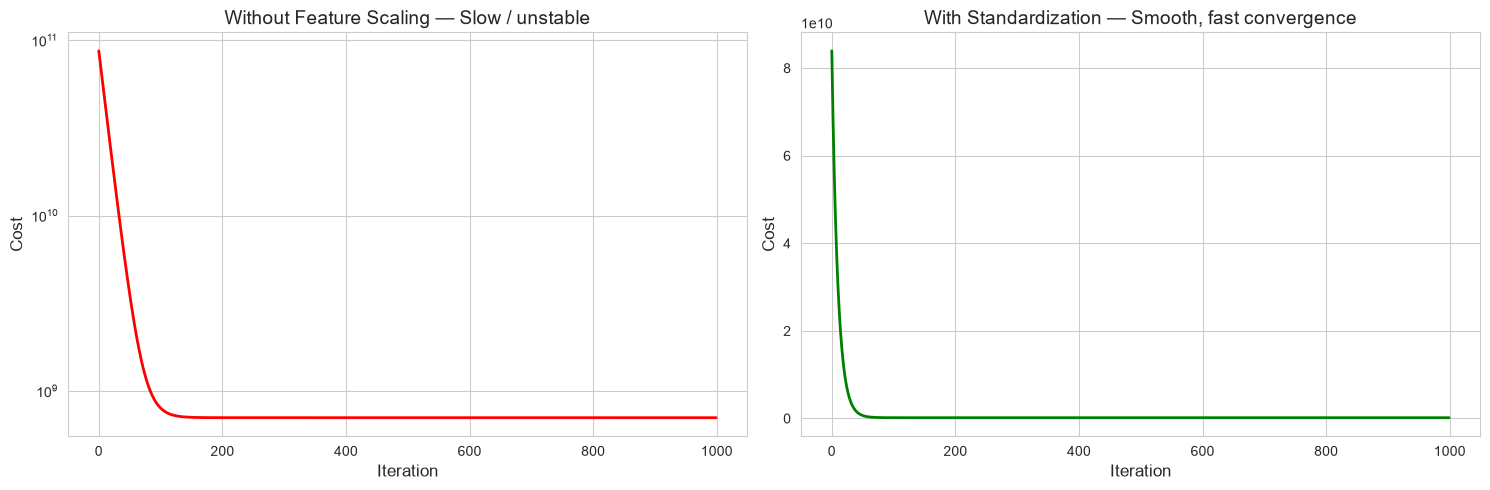

In [22]:
def compute_cost_multi(X, y, theta):
    m = len(y)
    predictions = X @ theta
    return (1 / (2 * m)) * np.sum((predictions - y) ** 2)

def gradient_descent_multi(X, y, alpha=0.01, iterations=1000):
    m, n = X.shape
    theta = np.zeros(n)
    cost_history = []

    for _ in range(iterations):
        predictions = X @ theta
        error = predictions - y
        gradient = (1 / m) * (X.T @ error)
        theta -= alpha * gradient
        cost_history.append(compute_cost_multi(X, y, theta))

    return theta, cost_history

# Demo: without vs with feature scaling
np.random.seed(0)
m_demo = 100
X_raw = np.column_stack([
    np.random.uniform(500, 3000, m_demo),   # size (500–3000)
    np.random.uniform(1, 5, m_demo),        # bedrooms (1–5)
    np.random.uniform(0, 30, m_demo)        # age (0–30)
])
y_demo = 50000 + 200*X_raw[:,0] + 10000*X_raw[:,1] - 500*X_raw[:,2] + np.random.normal(0, 20000, m_demo)

# Without scaling
X_unscaled = np.column_stack([np.ones(m_demo), X_raw])
_, cost_unscaled = gradient_descent_multi(X_unscaled, y_demo, alpha=1e-8, iterations=1000)

# With standardization
X_scaled_raw = (X_raw - X_raw.mean(axis=0)) / X_raw.std(axis=0)
X_scaled = np.column_stack([np.ones(m_demo), X_scaled_raw])
_, cost_scaled = gradient_descent_multi(X_scaled, y_demo, alpha=0.05, iterations=1000)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
axes[0].plot(cost_unscaled, color='red', linewidth=2)
axes[0].set_title('Without Feature Scaling — Slow / unstable')
axes[0].set_xlabel('Iteration')
axes[0].set_ylabel('Cost')
axes[0].set_yscale('log')

axes[1].plot(cost_scaled, color='green', linewidth=2)
axes[1].set_title('With Standardization — Smooth, fast convergence')
axes[1].set_xlabel('Iteration')
axes[1].set_ylabel('Cost')

plt.tight_layout()
plt.show()

## 4. Solving It in One Shot: OLS (the Normal Equation)

Gradient descent *inches* toward the answer over many rounds. But for linear regression there's a shortcut: a formula that jumps straight to the best weights in a **single calculation**, no stepping required. It's called the **Normal Equation**, and the method is known as **Ordinary Least Squares (OLS)**:

$$\boxed{\boldsymbol{\theta} = (\mathbf{X}^T \mathbf{X})^{-1} \mathbf{X}^T \mathbf{y}}$$

You plug in your data (X) and answers (y), do the matrix arithmetic, and out come the exact best weights. (`Xᵀ` means "X transposed" — rows and columns flipped — and the `⁻¹` means "matrix inverse," a matrix version of division.)

### Where Does This Formula Come From? (Optional)

If you know a bit of calculus, here's the logic in 4 lines. The best weights are the ones where the cost stops decreasing — i.e. where its slope (gradient) is exactly zero:

1. Cost: $J(\theta) = \frac{1}{2m}(X\theta - y)^T(X\theta - y)$
2. Find its slope with respect to θ: $\nabla_\theta J = \frac{1}{m} X^T(X\theta - y)$
3. Set the slope to zero (bottom of the valley): $X^T X \theta = X^T y$
4. Rearrange to solve for θ: $\theta = (X^T X)^{-1} X^T y$

### Gradient Descent vs OLS — Which Should I Use?

Both find the *same* best-fit line. They just take different routes:

| Question | Gradient Descent | OLS (Normal Equation) |
|---|---|---|
| Need to pick a learning rate? | Yes | No |
| How many steps? | Many (loops) | Just one |
| Need feature scaling? | Yes | No |
| Cost as features grow | Cheap per step | Expensive (inverting a big matrix) |
| Works with tons of features (>10,000)? | Yes | Slow / impractical |
| What if the matrix can't be inverted? | Still works | Fails (need a pseudo-inverse) |
| Best for | Big data, ML pipelines | Small / medium datasets, exact answer |

**Short version:** small dataset → use OLS for an instant exact answer. Huge dataset → use gradient descent because it scales.

In [23]:
def ols_fit(X, y):
    """Solve theta = (X^T X)^-1 X^T y"""
    return np.linalg.inv(X.T @ X) @ X.T @ y

# Fit our house-price demo with OLS
X_ols = np.column_stack([np.ones(m_demo), X_raw])
theta_ols = ols_fit(X_ols, y_demo)

print('=== OLS Estimates ===')
print(f'θ₀ (intercept)       = {theta_ols[0]:>12,.2f}')
print(f'θ₁ (per sqft)        = {theta_ols[1]:>12,.2f}')
print(f'θ₂ (per bedroom)     = {theta_ols[2]:>12,.2f}')
print(f'θ₃ (per year of age) = {theta_ols[3]:>12,.2f}')

print('\n=== True (generating) coefficients ===')
print('θ₀ = 50,000, θ₁ = 200, θ₂ = 10,000, θ₃ = -500')
print('\nOLS recovered them accurately (small differences are due to noise in the data).')

=== OLS Estimates ===
θ₀ (intercept)       =    58,856.94
θ₁ (per sqft)        =       195.49
θ₂ (per bedroom)     =     7,929.85
θ₃ (per year of age) =      -334.75

=== True (generating) coefficients ===
θ₀ = 50,000, θ₁ = 200, θ₂ = 10,000, θ₃ = -500

OLS recovered them accurately (small differences are due to noise in the data).


## 5. Measuring Error: MAE, MSE, RMSE

Once we've trained a model, the obvious question is: **how good is it?** For that we measure the **residuals** — the gaps between the true values and our predictions (residual = actual − predicted). Here are the three most common ways to summarize those gaps into a single number.

### 5.1 MAE — Mean Absolute Error

$$MAE = \frac{1}{m} \sum_{i=1}^{m} |y_i - \hat{y}_i|$$

**In plain words:** take each gap, drop the minus sign (that's what the `| |` bars mean — "absolute value"), and average them. It's literally "on average, how far off are we?"

- Reported in the **same units as Y** (if Y is rupees, MAE is in rupees) — very easy to explain.
- **Not thrown off by outliers:** one weird data point adds to the error only in proportion to how wrong it is, not more.

### 5.2 MSE — Mean Squared Error

$$MSE = \frac{1}{m} \sum_{i=1}^{m} (y_i - \hat{y}_i)^2$$

**In plain words:** same idea, but *square* each gap before averaging. Squaring does two things: it removes minus signs automatically, and it makes big mistakes count *way* more than small ones (an error of 10 becomes 100).

- Units are Y **squared** (rupees², which is odd to interpret directly).
- **Punishes large errors heavily** — a single big outlier can dominate the whole score.
- Its smooth, bowl-like shape is easy to do calculus on, which is exactly why gradient descent uses it.

### 5.3 RMSE — Root Mean Squared Error

$$RMSE = \sqrt{MSE} = \sqrt{\frac{1}{m} \sum (y_i - \hat{y}_i)^2}$$

**In plain words:** just the square root of MSE. Taking the root undoes the squaring, so we're **back in the original units of Y** — readable again, but still with MSE's habit of punishing big errors.

- The most commonly reported error metric in machine learning.
- Still sensitive to outliers (since it's built on MSE).

### Which One Should I Use?

| Your situation | Best metric |
|---|---|
| Data has outliers and you want a robust number | **MAE** |
| Big mistakes are much worse than small ones | **MSE** or **RMSE** |
| You want a number in the same units as Y | **MAE** or **RMSE** |
| You're comparing against other models / a benchmark | **RMSE** (the industry default) |

In [24]:
# Small worked example
y_true = np.array([100, 150, 200, 250, 300])
y_pred_ex = np.array([110, 140, 210, 240, 290])

errors = y_true - y_pred_ex
abs_err = np.abs(errors)
sq_err = errors ** 2

df_metrics = pd.DataFrame({
    'y (actual)': y_true,
    'ŷ (predicted)': y_pred_ex,
    'error (y - ŷ)': errors,
    '|error|': abs_err,
    'error²': sq_err
})
print('Step-by-step calculation:\n')
print(df_metrics.to_string(index=False))

mae = abs_err.mean()
mse = sq_err.mean()
rmse = np.sqrt(mse)

print(f'\nMAE  = mean(|error|) = ({" + ".join(map(str, abs_err))}) / 5 = {mae}')
print(f'MSE  = mean(error²)  = ({" + ".join(map(str, sq_err))}) / 5 = {mse}')
print(f'RMSE = √MSE          = √{mse} = {rmse:.4f}')

Step-by-step calculation:

 y (actual)  ŷ (predicted)  error (y - ŷ)  |error|  error²
        100            110            -10       10     100
        150            140             10       10     100
        200            210            -10       10     100
        250            240             10       10     100
        300            290             10       10     100

MAE  = mean(|error|) = (10 + 10 + 10 + 10 + 10) / 5 = 10.0
MSE  = mean(error²)  = (100 + 100 + 100 + 100 + 100) / 5 = 100.0
RMSE = √MSE          = √100.0 = 10.0000


Effect of ONE outlier on each metric:

Metric Clean data With 1 outlier Multiplier
   MAE      0.243          1.943       ×8.0
   MSE      0.076         20.646     ×272.7
  RMSE      0.275          4.544      ×16.5

MSE blew up because it squared the huge outlier residual. MAE only grew linearly.


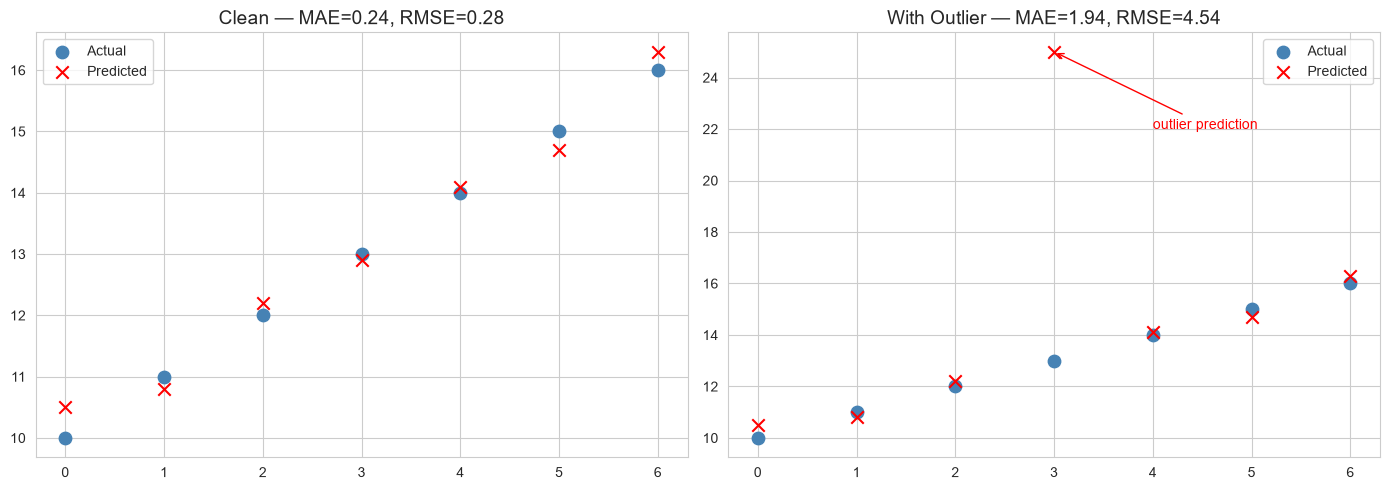

In [25]:
# Show that MSE/RMSE penalize outliers more than MAE
np.random.seed(2)
y_clean = np.array([10, 11, 12, 13, 14, 15, 16])
y_pred_clean = np.array([10.5, 10.8, 12.2, 12.9, 14.1, 14.7, 16.3])

y_out = y_clean.copy()
y_pred_out = y_pred_clean.copy()
y_pred_out[3] = 25   # introduce a huge outlier

def all_metrics(y, yhat):
    err = y - yhat
    return np.mean(np.abs(err)), np.mean(err**2), np.sqrt(np.mean(err**2))

mae_c, mse_c, rmse_c = all_metrics(y_clean, y_pred_clean)
mae_o, mse_o, rmse_o = all_metrics(y_out, y_pred_out)

compare = pd.DataFrame({
    'Metric': ['MAE', 'MSE', 'RMSE'],
    'Clean data': [f'{mae_c:.3f}', f'{mse_c:.3f}', f'{rmse_c:.3f}'],
    'With 1 outlier': [f'{mae_o:.3f}', f'{mse_o:.3f}', f'{rmse_o:.3f}'],
    'Multiplier': [f'×{mae_o/mae_c:.1f}', f'×{mse_o/mse_c:.1f}', f'×{rmse_o/rmse_c:.1f}']
})
print('Effect of ONE outlier on each metric:\n')
print(compare.to_string(index=False))
print('\nMSE blew up because it squared the huge outlier residual. MAE only grew linearly.')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].scatter(range(len(y_clean)), y_clean, s=80, color='steelblue', label='Actual')
axes[0].scatter(range(len(y_pred_clean)), y_pred_clean, s=80, color='red', marker='x', label='Predicted')
axes[0].set_title(f'Clean — MAE={mae_c:.2f}, RMSE={rmse_c:.2f}')
axes[0].legend()

axes[1].scatter(range(len(y_out)), y_out, s=80, color='steelblue', label='Actual')
axes[1].scatter(range(len(y_pred_out)), y_pred_out, s=80, color='red', marker='x', label='Predicted')
axes[1].annotate('outlier prediction', xy=(3, 25), xytext=(4, 22),
                 arrowprops=dict(arrowstyle='->', color='red'), color='red')
axes[1].set_title(f'With Outlier — MAE={mae_o:.2f}, RMSE={rmse_o:.2f}')
axes[1].legend()
plt.tight_layout()
plt.show()

## 6. Measuring Fit: R² and Adjusted R²

MAE, MSE, and RMSE tell you the **size** of your error (e.g. "off by ₹20,000 on average"). But is ₹20,000 good or bad? That depends on the data. **R²** gives you a *relative* score instead: a single number, usually between 0 and 1, that says how much of the pattern your model captured — no units, easy to compare across problems.

### 6.1 R² — the Coefficient of Determination

$$R^2 = 1 - \frac{SS_{res}}{SS_{tot}} = 1 - \frac{\sum (y_i - \hat{y}_i)^2}{\sum (y_i - \bar{y})^2}$$

Here's the intuition. Imagine a lazy "model" that ignores the inputs and always predicts the **average** of Y ($\bar{y}$, read "y-bar"). R² asks: *how much better is my real model than that lazy baseline?*

- `SS_res` = leftover error from *your* model (residual sum of squares).
- `SS_tot` = error of the lazy average-only model (total sum of squares).

So R² is "1 minus the fraction of error you still have left." Reading the score:

- **R² = 1** → perfect predictions, zero error.
- **R² = 0** → your model is no better than just guessing the average.
- **R² < 0** → your model is *worse* than guessing the average (rare, and usually a red flag on test data).

A handy sentence: *"the features explain R² × 100% of the variation in Y."* For example, R² = 0.85 means "85% of what makes Y move is captured by the model."

### 6.2 Adjusted R² — R²'s Honest Sibling

**The catch with R²:** it can only go *up* (or stay flat) when you add a new feature — **even a completely useless, random one.** So you could pile on 100 junk features, watch R² creep higher, and fool yourself into thinking the model improved.

**The fix — Adjusted R²** adds a penalty for each feature you use, so junk features actually *hurt* the score:

$$R^2_{adj} = 1 - \frac{(1 - R^2)(n - 1)}{n - k - 1}$$

Where:
- **n** = number of data examples.
- **k** = number of features you're using.

Because it can go *down* when you add a worthless feature, Adjusted R² is the fairer number to use whenever you're comparing models that have **different numbers of features.**

             Model       R²  Adjusted R²
    1 real feature 0.893076     0.891985
 + 1 junk features 0.893422     0.891225
 + 2 junk features 0.893461     0.890131
 + 3 junk features 0.893610     0.889130
 + 4 junk features 0.894379     0.888761
 + 5 junk features 0.897593     0.890986
 + 6 junk features 0.897640     0.889852
 + 7 junk features 0.899597     0.890771
 + 8 junk features 0.900479     0.890527
 + 9 junk features 0.900552     0.889378
+ 10 junk features 0.901658     0.889365


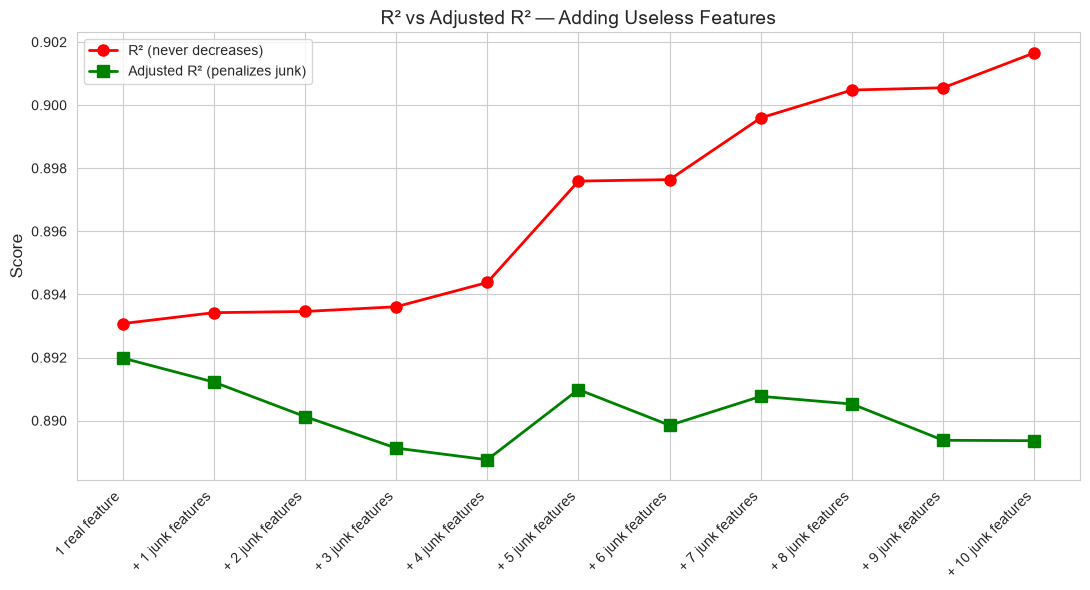

In [26]:
# Demo: R² can never go down when adding features, but Adj R² can
np.random.seed(5)
n_samples = 100
X_real = np.random.uniform(0, 10, n_samples)
y_target = 3 + 2 * X_real + np.random.normal(0, 2, n_samples)

def r2_and_adj(X_features, y):
    X_bias = np.column_stack([np.ones(len(y)), X_features])
    theta = ols_fit(X_bias, y)
    y_hat = X_bias @ theta
    ss_res = np.sum((y - y_hat) ** 2)
    ss_tot = np.sum((y - y.mean()) ** 2)
    r2 = 1 - ss_res / ss_tot
    n = len(y)
    k = X_features.shape[1] if X_features.ndim > 1 else 1
    adj_r2 = 1 - (1 - r2) * (n - 1) / (n - k - 1)
    return r2, adj_r2

# Start with only the real feature
results = []
features_so_far = X_real.reshape(-1, 1)
r2_v, adj_v = r2_and_adj(features_so_far, y_target)
results.append(('1 real feature', r2_v, adj_v))

# Add junk features one by one
for i in range(1, 11):
    junk = np.random.normal(0, 1, n_samples).reshape(-1, 1)
    features_so_far = np.hstack([features_so_far, junk])
    r2_v, adj_v = r2_and_adj(features_so_far, y_target)
    results.append((f'+ {i} junk features', r2_v, adj_v))

df_r2 = pd.DataFrame(results, columns=['Model', 'R²', 'Adjusted R²'])
print(df_r2.to_string(index=False))

plt.figure(figsize=(11, 6))
plt.plot(range(len(df_r2)), df_r2['R²'], 'o-', color='red', linewidth=2, markersize=8, label='R² (never decreases)')
plt.plot(range(len(df_r2)), df_r2['Adjusted R²'], 's-', color='green', linewidth=2, markersize=8, label='Adjusted R² (penalizes junk)')
plt.xticks(range(len(df_r2)), df_r2['Model'], rotation=45, ha='right')
plt.ylabel('Score')
plt.title('R² vs Adjusted R² — Adding Useless Features')
plt.legend()
plt.tight_layout()
plt.show()

## 7. Overfitting and Underfitting

Here's the whole point of machine learning: we don't care how well the model does on data it has *already seen* — we care how well it does on **new, unseen data**. That ability is called **generalization**, and there are two classic ways to fail at it.

To spot them, we split our data into a **training set** (used to fit the model) and a **test set** (held back, used only to check how it does on data it never saw). Comparing performance on the two sets is how we diagnose the problem.

### Underfitting (also called "High Bias")
- The model is **too simple** to capture the real pattern.
- It does **badly on training data AND badly on test data** — it never really learned.
- Classic example: drawing a straight line through data that's obviously curved.
- **How to fix:** use a more flexible model, add more useful features, or ease off any regularization.

### Good Fit (the goal)
- The model captures the genuine underlying trend without obsessing over every wiggle.
- Performance on training and test data is **similar and good.**
- This is the **sweet spot** we're aiming for.

### Overfitting (also called "High Variance")
- The model is **too complex** — instead of learning the pattern, it memorizes the random noise in the training data.
- It looks **amazing on training data but fails on test data** — it can't handle anything new.
- Classic example: forcing a wildly wiggly 15-degree curve through 20 noisy points so it hits each one exactly.
- **How to fix:** get more training data, use a simpler model, apply regularization (Ridge/Lasso), use cross-validation, or stop training earlier.

**The pattern to remember:** underfit = bad everywhere; overfit = great on training, bad on test; good fit = good and consistent on both.

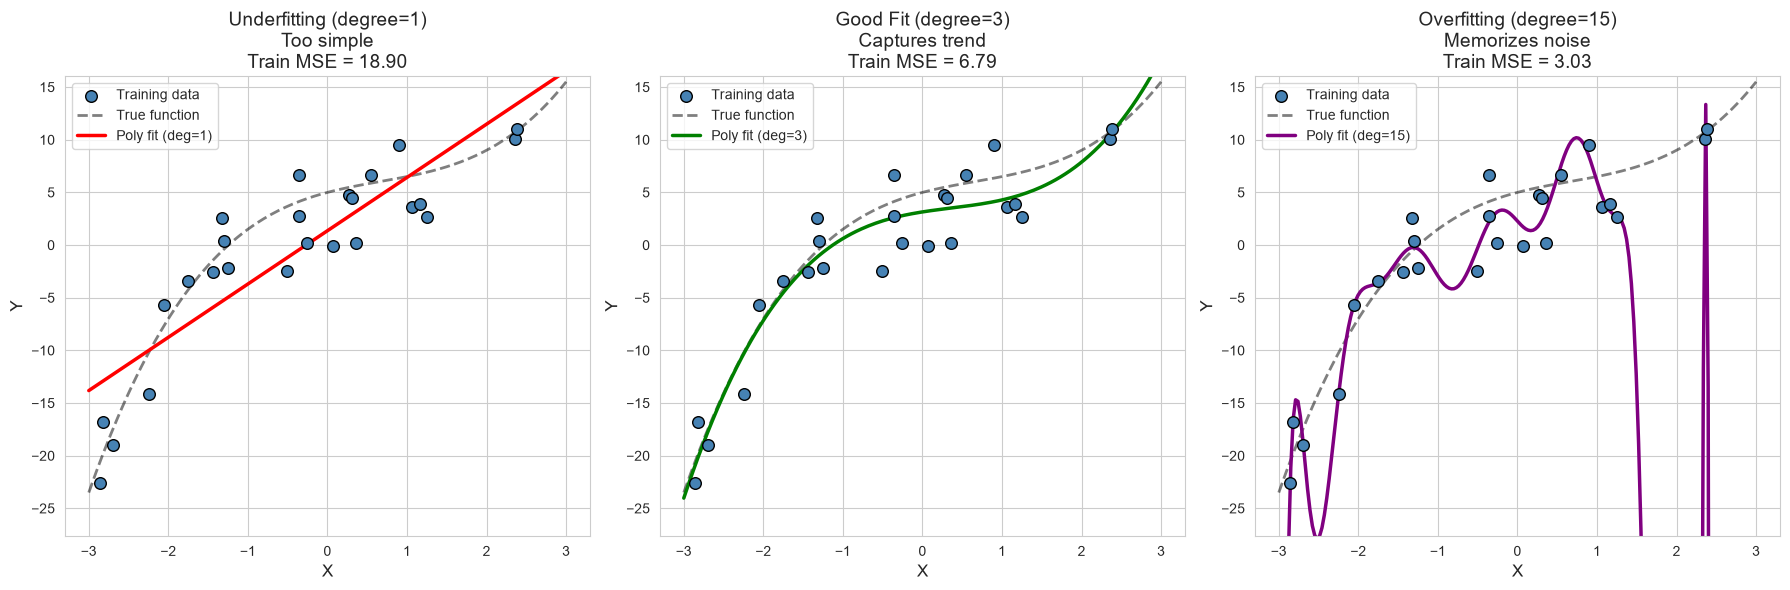

In [27]:
# Visualize underfitting, good fit, overfitting
np.random.seed(3)
X_o = np.sort(np.random.uniform(-3, 3, 25))
y_true_o = 0.5 * X_o ** 3 - X_o ** 2 + 2 * X_o + 5
y_o = y_true_o + np.random.normal(0, 3, len(X_o))

X_plot = np.linspace(-3, 3, 200)
y_true_plot = 0.5 * X_plot ** 3 - X_plot ** 2 + 2 * X_plot + 5

degrees = [1, 3, 15]
titles = ['Underfitting (degree=1)\nToo simple', 'Good Fit (degree=3)\nCaptures trend',
          'Overfitting (degree=15)\nMemorizes noise']
colors_fit = ['red', 'green', 'purple']

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for ax, deg, title, col in zip(axes, degrees, titles, colors_fit):
    coef = np.polyfit(X_o, y_o, deg)
    y_plot_fit = np.polyval(coef, X_plot)
    y_train_fit = np.polyval(coef, X_o)

    ax.scatter(X_o, y_o, s=70, color='steelblue', edgecolor='black', label='Training data', zorder=3)
    ax.plot(X_plot, y_true_plot, 'k--', linewidth=2, alpha=0.5, label='True function')
    ax.plot(X_plot, y_plot_fit, color=col, linewidth=2.5, label=f'Poly fit (deg={deg})')

    train_mse = np.mean((y_o - y_train_fit) ** 2)
    ax.set_title(f'{title}\nTrain MSE = {train_mse:.2f}')
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.legend()
    ax.set_ylim(y_o.min() - 5, y_o.max() + 5)

plt.tight_layout()
plt.show()

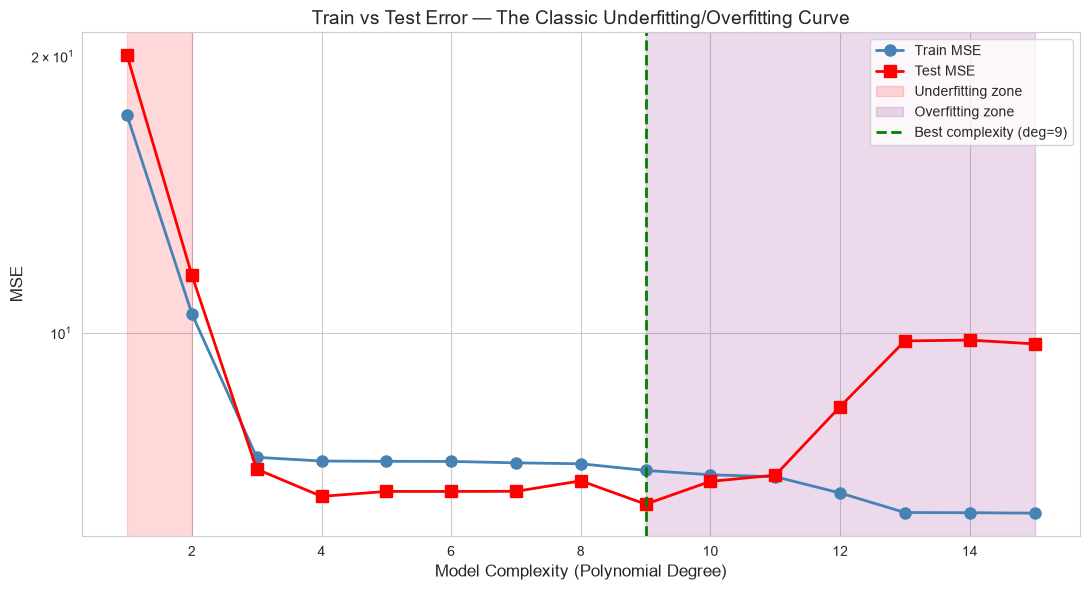

KEY INSIGHT:
- Train error keeps decreasing as complexity grows (model memorizes more).
- Test error decreases, then INCREASES — that's overfitting.
- The sweet spot is where test error is lowest.


In [28]:
# Train vs Test error as complexity grows — the classic U-shape
np.random.seed(4)
X_all = np.random.uniform(-3, 3, 100)
y_all = 0.5 * X_all ** 3 - X_all ** 2 + 2 * X_all + 5 + np.random.normal(0, 3, 100)

# 70/30 split
idx = np.random.permutation(100)
train_idx, test_idx = idx[:70], idx[70:]
X_train, X_test = X_all[train_idx], X_all[test_idx]
y_train, y_test = y_all[train_idx], y_all[test_idx]

degrees_range = range(1, 16)
train_errs, test_errs = [], []
for d in degrees_range:
    coef = np.polyfit(X_train, y_train, d)
    train_errs.append(np.mean((y_train - np.polyval(coef, X_train)) ** 2))
    test_errs.append(np.mean((y_test - np.polyval(coef, X_test)) ** 2))

plt.figure(figsize=(11, 6))
plt.plot(degrees_range, train_errs, 'o-', color='steelblue', linewidth=2, markersize=8, label='Train MSE')
plt.plot(degrees_range, test_errs, 's-', color='red', linewidth=2, markersize=8, label='Test MSE')
plt.axvspan(1, 2, alpha=0.15, color='red', label='Underfitting zone')
plt.axvspan(9, 15, alpha=0.15, color='purple', label='Overfitting zone')
best_d = degrees_range[np.argmin(test_errs)]
plt.axvline(x=best_d, color='green', linestyle='--', linewidth=2, label=f'Best complexity (deg={best_d})')
plt.xlabel('Model Complexity (Polynomial Degree)')
plt.ylabel('MSE')
plt.title('Train vs Test Error — The Classic Underfitting/Overfitting Curve')
plt.yscale('log')
plt.legend()
plt.tight_layout()
plt.show()

print('KEY INSIGHT:')
print('- Train error keeps decreasing as complexity grows (model memorizes more).')
print('- Test error decreases, then INCREASES — that\'s overfitting.')
print('- The sweet spot is where test error is lowest.')

## 8. The Bias-Variance Tradeoff

Overfitting and underfitting are really two sides of one deeper idea. Any model's expected error can be broken into three parts:

$$\text{Total Error} = \text{Bias}^2 + \text{Variance} + \text{Irreducible Noise}$$

| Term | What it means (plain English) |
|---|---|
| **Bias** | How far off the model is *on average* — does it systematically miss the truth? |
| **Variance** | How much the model *changes* if you retrain it on a different sample of data — is it jumpy and unstable? |
| **Noise** | Pure randomness baked into the data itself. No model can ever remove this part. |

The "tradeoff" is that bias and variance pull against each other: making a model more complex lowers bias but raises variance, and vice versa. Our job is to find the balance:

| Scenario | Bias | Variance |
|---|---|---|
| Underfitting (too simple) | HIGH | LOW |
| Overfitting (too complex) | LOW | HIGH |
| Just right | LOW | LOW |

### The Dartboard Analogy

Think of throwing darts at a target. **Bias** is *where* your throws cluster (near the bullseye or off to one side). **Variance** is how *spread out* they are.

```
Low Bias, Low Variance      Low Bias, High Variance    High Bias, Low Variance    High Bias, High Variance
     (Perfect)                  (Overfitting)              (Underfitting)                (Worst)

        *                          *  *                                                 *
       ***                        *    *                    * *                       *
        *                          *  *                    *****                        *  *
                                                            * *
  All in the center           Scattered near center     Grouped, but off-center     Scattered AND off-center
```

- **Low bias + low variance:** tight cluster on the bullseye — exactly what we want.
- **Low bias + high variance (overfitting):** centered on average, but throws are all over the place.
- **High bias + low variance (underfitting):** throws are consistent with each other, but consistently in the wrong spot.
- **High bias + high variance:** scattered *and* off-target — the worst of both.

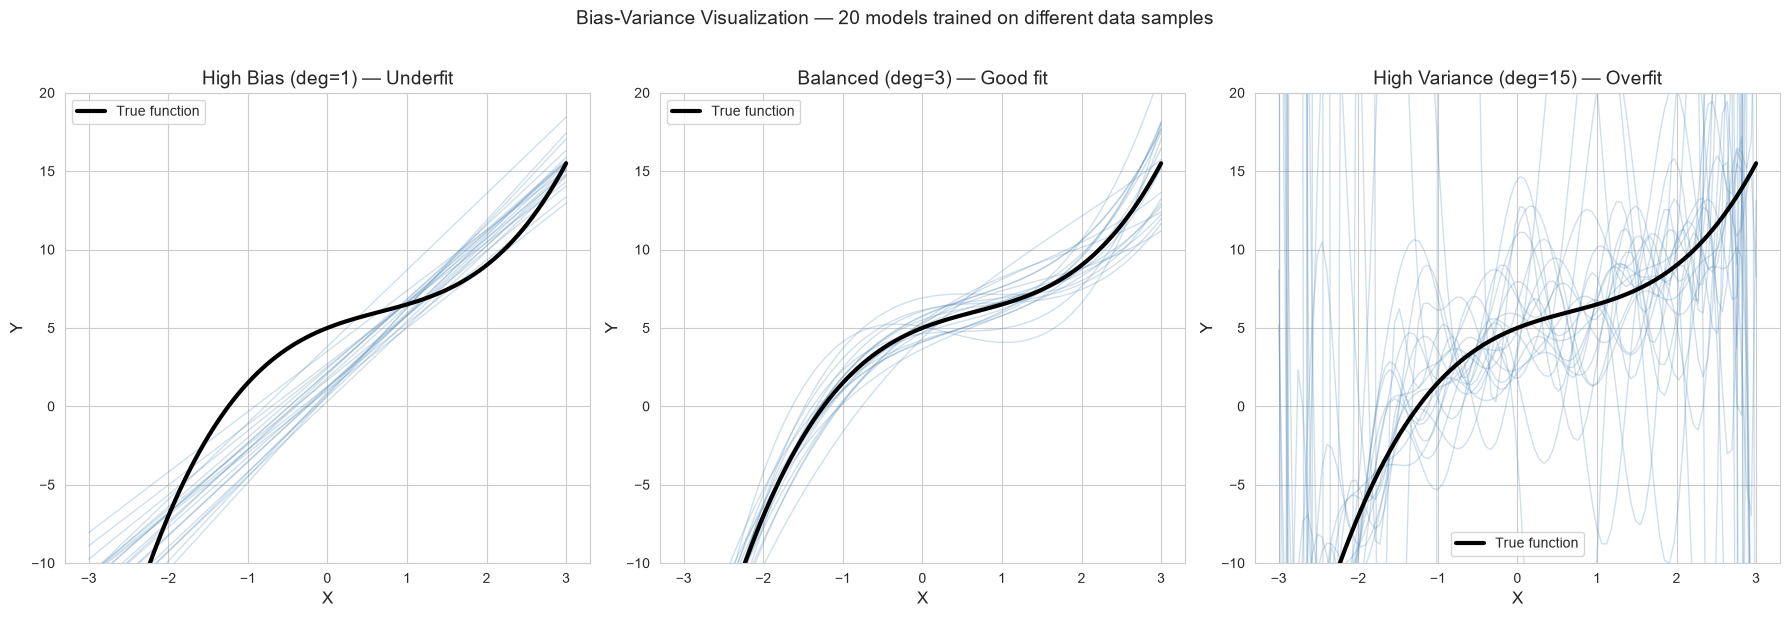

- Left: All 20 fits look SIMILAR (low variance) but far from truth (high bias).
- Middle: Fits are close to truth AND consistent (low bias + low variance).
- Right: Fits WILDLY DIFFERENT (high variance) — each memorizes a different sample.


In [29]:
# Simulate bias-variance visually: train the same model 20 times on different data samples
np.random.seed(0)

def true_fn(x):
    return 0.5 * x ** 3 - x ** 2 + 2 * x + 5

X_plot = np.linspace(-3, 3, 100)
y_true_plot = true_fn(X_plot)

n_trials = 20
degrees_to_show = [1, 3, 15]
titles_bv = ['High Bias (deg=1) — Underfit',
             'Balanced (deg=3) — Good fit',
             'High Variance (deg=15) — Overfit']

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for ax, deg, title in zip(axes, degrees_to_show, titles_bv):
    for _ in range(n_trials):
        X_samp = np.random.uniform(-3, 3, 25)
        y_samp = true_fn(X_samp) + np.random.normal(0, 3, 25)
        coef = np.polyfit(X_samp, y_samp, deg)
        ax.plot(X_plot, np.polyval(coef, X_plot), color='steelblue', alpha=0.25, linewidth=1)
    ax.plot(X_plot, y_true_plot, 'k-', linewidth=3, label='True function')
    ax.set_title(title)
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_ylim(-10, 20)
    ax.legend()

plt.suptitle('Bias-Variance Visualization — 20 models trained on different data samples',
             fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print('- Left: All 20 fits look SIMILAR (low variance) but far from truth (high bias).')
print('- Middle: Fits are close to truth AND consistent (low bias + low variance).')
print('- Right: Fits WILDLY DIFFERENT (high variance) — each memorizes a different sample.')

## 9. Full Worked Example — Predicting House Prices

Time to put every piece together. We'll take a realistic dataset with several features and walk through the complete workflow a data scientist actually follows:

1. **Look at the data** (explore it and check how features relate to price).
2. **Split** it into training and test sets.
3. **Train** the model with OLS.
4. **Read** the learned weights to understand what drives the price.
5. **Evaluate** it with the metrics from Sections 5 & 6.
6. **Predict** prices for brand-new houses.

This is the same end-to-end process you'd use on any regression problem.

In [30]:
# Realistic dataset (~50 houses)
np.random.seed(7)
n = 50
size = np.random.uniform(800, 3500, n).round(0)
bedrooms = np.random.choice([1, 2, 3, 4, 5], n, p=[0.05, 0.2, 0.4, 0.25, 0.1])
age = np.random.uniform(0, 40, n).round(0)
bathrooms = np.random.choice([1, 2, 3, 4], n, p=[0.1, 0.4, 0.35, 0.15])

price = (50000 + 200*size + 10000*bedrooms - 800*age + 15000*bathrooms
         + np.random.normal(0, 25000, n)).round(0)

df_house = pd.DataFrame({
    'Size_sqft': size,
    'Bedrooms': bedrooms,
    'Age_yrs': age,
    'Bathrooms': bathrooms,
    'Price': price
})
print('First 10 rows:')
print(df_house.head(10).to_string(index=False))
print(f'\nDataset shape: {df_house.shape}')
print(f'\nSummary:')
print(df_house.describe().round(2))

First 10 rows:
 Size_sqft  Bedrooms  Age_yrs  Bathrooms    Price
    1006.0         3      3.0          1 254893.0
    2906.0         3     14.0          3 713968.0
    1984.0         3     33.0          3 525557.0
    2753.0         3     17.0          2 671514.0
    3441.0         3     24.0          2 755767.0
    2254.0         1     29.0          2 527895.0
    2153.0         2     33.0          3 565701.0
     995.0         4     30.0          4 287568.0
    1525.0         3      0.0          4 456908.0
    2150.0         4     17.0          2 564207.0

Dataset shape: (50, 5)

Summary:
       Size_sqft  Bedrooms  Age_yrs  Bathrooms      Price
count      50.00     50.00    50.00      50.00      50.00
mean     2168.42      3.26    18.44       2.50  537722.82
std       704.96      0.94    12.46       0.89  144244.00
min       867.00      1.00     0.00       1.00  254893.00
25%      1674.25      3.00     7.00       2.00  450913.50
50%      2107.00      3.00    18.50       2.00  53060

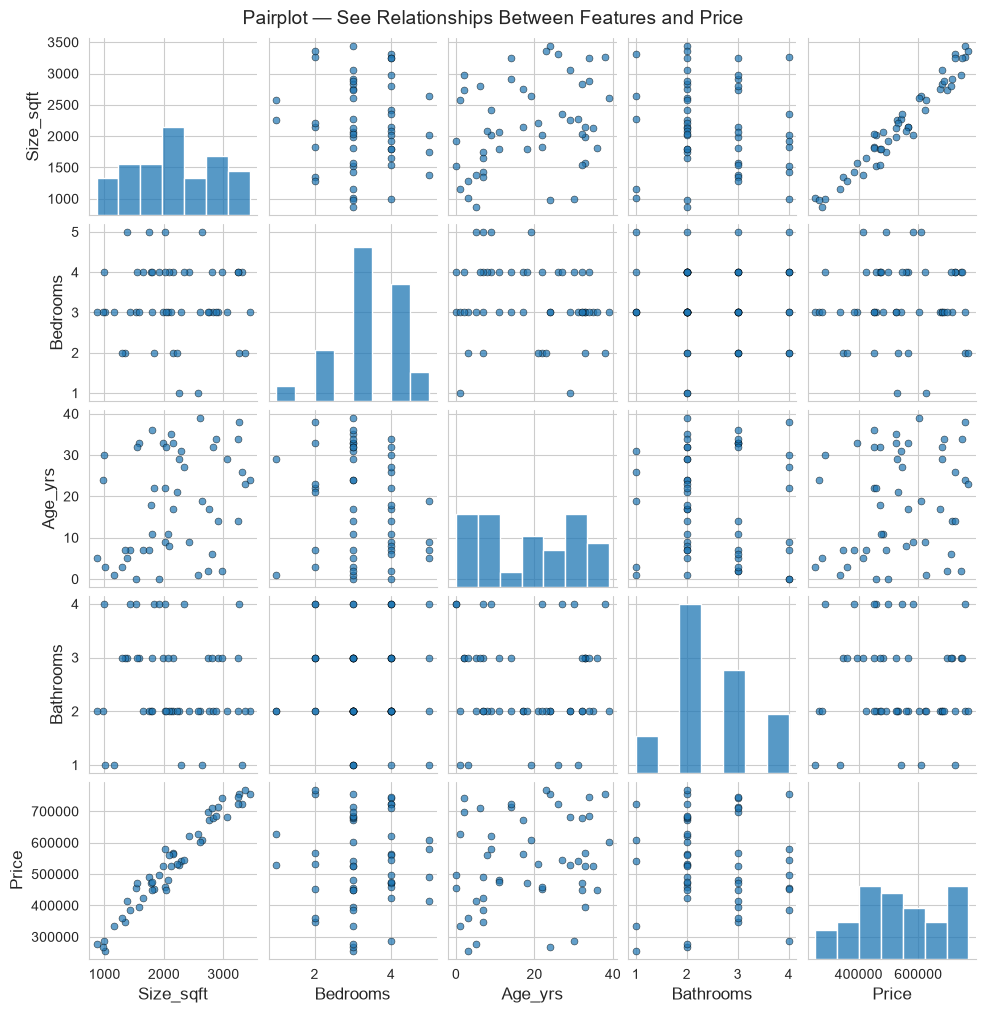

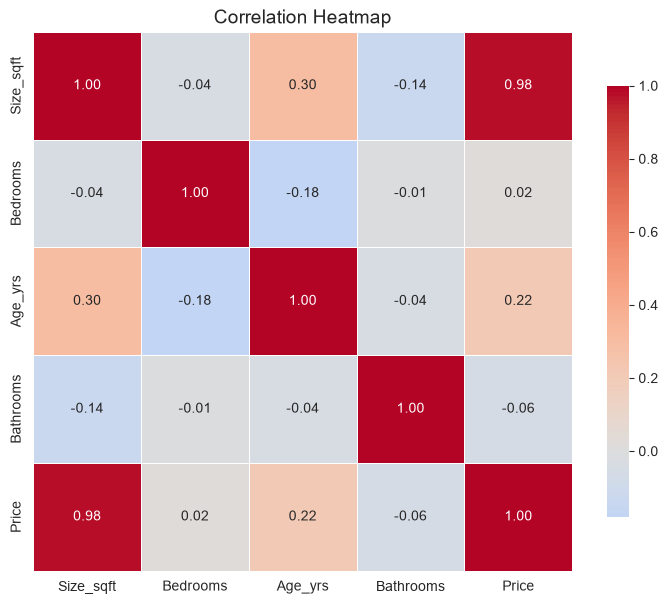

In [31]:
# EDA — pairwise relationships & correlation heatmap
sns.pairplot(df_house, height=2.0, plot_kws={'s': 25, 'alpha': 0.7, 'edgecolor': 'k'})
plt.suptitle('Pairplot — See Relationships Between Features and Price', y=1.01, fontsize=14)
plt.show()

plt.figure(figsize=(9, 7))
sns.heatmap(df_house.corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5, cbar_kws={'shrink': 0.8})
plt.title('Correlation Heatmap')
plt.show()

In [32]:
# Train/test split
np.random.seed(1)
shuffled = np.random.permutation(n)
train_idx = shuffled[:int(0.8*n)]
test_idx = shuffled[int(0.8*n):]

X_all = df_house[['Size_sqft', 'Bedrooms', 'Age_yrs', 'Bathrooms']].values
y_all = df_house['Price'].values

X_train, X_test = X_all[train_idx], X_all[test_idx]
y_train, y_test = y_all[train_idx], y_all[test_idx]

# Add bias column
X_train_b = np.column_stack([np.ones(len(X_train)), X_train])
X_test_b = np.column_stack([np.ones(len(X_test)), X_test])

# Fit with OLS
theta_house = ols_fit(X_train_b, y_train)

feature_names = ['Intercept', 'Size (per sqft)', 'Bedrooms', 'Age (per yr)', 'Bathrooms']
print('=== Fitted Model Coefficients ===')
for name, val in zip(feature_names, theta_house):
    print(f'  {name:20s} = ₹{val:>12,.2f}')

print('\nInterpretation:')
print(f'  Every extra sq ft adds ~₹{theta_house[1]:,.0f}')
print(f'  Every extra bedroom adds ~₹{theta_house[2]:,.0f}')
print(f'  Every year of age reduces price by ~₹{-theta_house[3]:,.0f}')
print(f'  Every extra bathroom adds ~₹{theta_house[4]:,.0f}')

=== Fitted Model Coefficients ===
  Intercept            = ₹   65,268.41
  Size (per sqft)      = ₹      203.93
  Bedrooms             = ₹    6,093.11
  Age (per yr)         = ₹     -828.95
  Bathrooms            = ₹   10,159.86

Interpretation:
  Every extra sq ft adds ~₹204
  Every extra bedroom adds ~₹6,093
  Every year of age reduces price by ~₹829
  Every extra bathroom adds ~₹10,160


In [33]:
# Evaluate on train and test
y_pred_train = X_train_b @ theta_house
y_pred_test = X_test_b @ theta_house

def all_metrics_labeled(y, yhat, k):
    err = y - yhat
    mae_v = np.mean(np.abs(err))
    mse_v = np.mean(err ** 2)
    rmse_v = np.sqrt(mse_v)
    ss_res = np.sum(err ** 2)
    ss_tot = np.sum((y - y.mean()) ** 2)
    r2_v = 1 - ss_res / ss_tot
    n_ = len(y)
    adj_r2_v = 1 - (1 - r2_v) * (n_ - 1) / (n_ - k - 1)
    return mae_v, mse_v, rmse_v, r2_v, adj_r2_v

train_metrics = all_metrics_labeled(y_train, y_pred_train, 4)
test_metrics = all_metrics_labeled(y_test, y_pred_test, 4)

df_perf = pd.DataFrame({
    'Metric': ['MAE', 'MSE', 'RMSE', 'R²', 'Adjusted R²'],
    'Train': [f'₹{train_metrics[0]:,.0f}', f'{train_metrics[1]:,.0f}',
              f'₹{train_metrics[2]:,.0f}', f'{train_metrics[3]:.4f}', f'{train_metrics[4]:.4f}'],
    'Test':  [f'₹{test_metrics[0]:,.0f}', f'{test_metrics[1]:,.0f}',
              f'₹{test_metrics[2]:,.0f}', f'{test_metrics[3]:.4f}', f'{test_metrics[4]:.4f}']
})
print('=== Model Performance ===\n')
print(df_perf.to_string(index=False))

# Diagnose
gap = train_metrics[3] - test_metrics[3]
print(f'\nR² gap (train − test) = {gap:.4f}')
if gap > 0.1:
    print('→ Possible overfitting: train much better than test.')
elif train_metrics[3] < 0.5:
    print('→ Possible underfitting: even train R² is low.')
else:
    print('→ Healthy fit: train and test scores are close.')

=== Model Performance ===

     Metric       Train        Test
        MAE     ₹22,943     ₹17,265
        MSE 729,873,343 433,400,205
       RMSE     ₹27,016     ₹20,818
         R²      0.9635      0.9790
Adjusted R²      0.9594      0.9622

R² gap (train − test) = -0.0155
→ Healthy fit: train and test scores are close.


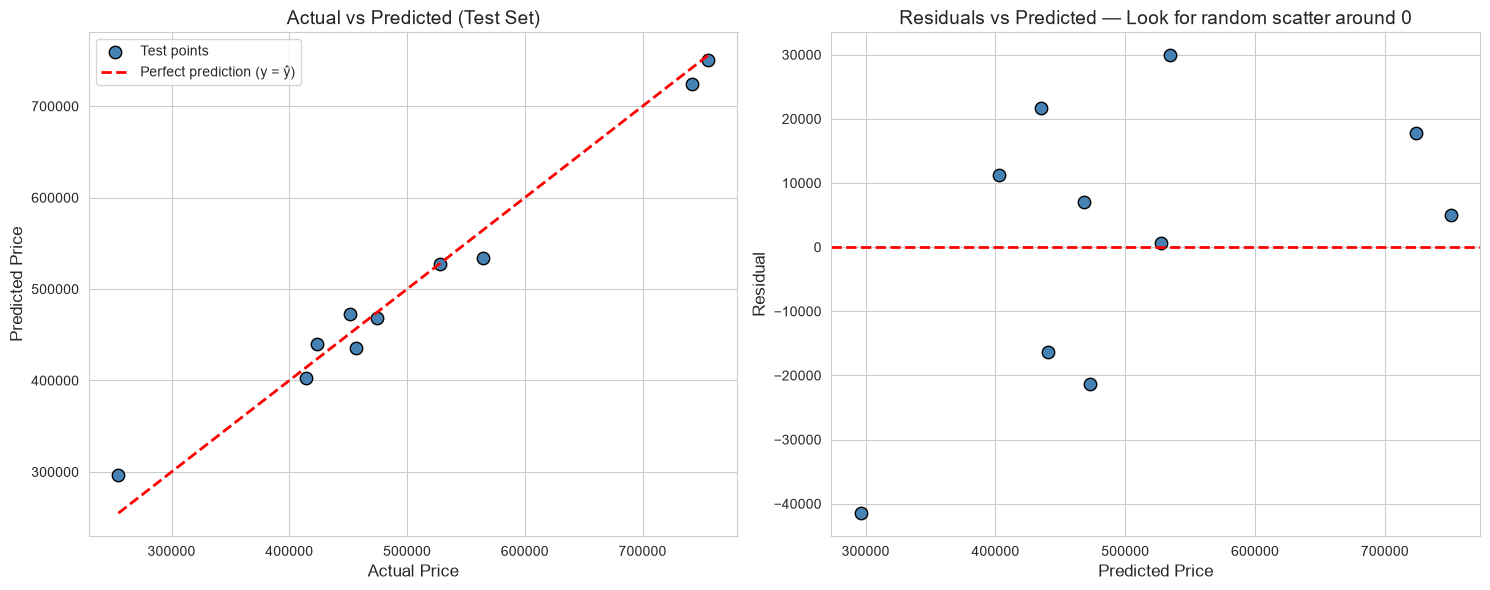

In [34]:
# Actual vs Predicted + Residuals plots
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Actual vs Predicted
axes[0].scatter(y_test, y_pred_test, s=80, color='steelblue', edgecolor='black', label='Test points')
lo, hi = min(y_test.min(), y_pred_test.min()), max(y_test.max(), y_pred_test.max())
axes[0].plot([lo, hi], [lo, hi], 'r--', linewidth=2, label='Perfect prediction (y = ŷ)')
axes[0].set_xlabel('Actual Price')
axes[0].set_ylabel('Predicted Price')
axes[0].set_title('Actual vs Predicted (Test Set)')
axes[0].legend()

# Residuals
residuals_test = y_test - y_pred_test
axes[1].scatter(y_pred_test, residuals_test, s=80, color='steelblue', edgecolor='black')
axes[1].axhline(y=0, color='red', linestyle='--', linewidth=2)
axes[1].set_xlabel('Predicted Price')
axes[1].set_ylabel('Residual')
axes[1].set_title('Residuals vs Predicted — Look for random scatter around 0')

plt.tight_layout()
plt.show()

In [35]:
# Predict for a few new houses
new_houses = pd.DataFrame({
    'Size_sqft': [1200, 2000, 2800, 3500],
    'Bedrooms':  [2, 3, 4, 5],
    'Age_yrs':   [15, 5, 2, 0],
    'Bathrooms': [1, 2, 3, 4]
})
new_X_b = np.column_stack([np.ones(len(new_houses)), new_houses.values])
preds = new_X_b @ theta_house

new_houses['Predicted Price'] = [f'₹{p:,.0f}' for p in preds]
print('=== Predictions for New Houses ===\n')
print(new_houses.to_string(index=False))

=== Predictions for New Houses ===

 Size_sqft  Bedrooms  Age_yrs  Bathrooms Predicted Price
      1200         2       15          1        ₹319,891
      2000         3        5          2        ₹507,574
      2800         4        2          3        ₹689,454
      3500         5        0          4        ₹850,113


## 10. Checking Our Work Against scikit-learn

We built our regression from scratch to understand *how* it works. But in real projects, everyone uses **scikit-learn** (`sklearn`) — a battle-tested library that does all this in a couple of lines.

Here's the reassuring part: since OLS gives one exact answer, our hand-written version should produce **exactly the same** weights and metrics as sklearn's `LinearRegression`. This is a great sanity check — if the numbers match, we know our from-scratch math was correct.

In [36]:
try:
    from sklearn.linear_model import LinearRegression
    from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

    model = LinearRegression()
    model.fit(X_train, y_train)

    y_pred_sk_test = model.predict(X_test)

    print('=== sklearn Coefficients ===')
    print(f'Intercept: ₹{model.intercept_:,.2f}')
    for name, val in zip(['Size', 'Bedrooms', 'Age', 'Bathrooms'], model.coef_):
        print(f'  {name:10s} = ₹{val:,.2f}')

    print('\n=== Our From-Scratch OLS Coefficients ===')
    print(f'Intercept: ₹{theta_house[0]:,.2f}')
    for name, val in zip(['Size', 'Bedrooms', 'Age', 'Bathrooms'], theta_house[1:]):
        print(f'  {name:10s} = ₹{val:,.2f}')

    print(f'\n=== Test-Set Metrics — sklearn ===')
    print(f'MAE  = ₹{mean_absolute_error(y_test, y_pred_sk_test):,.2f}')
    print(f'RMSE = ₹{np.sqrt(mean_squared_error(y_test, y_pred_sk_test)):,.2f}')
    print(f'R²   = {r2_score(y_test, y_pred_sk_test):.4f}')

    print(f'\n=== Test-Set Metrics — Our OLS ===')
    print(f'MAE  = ₹{test_metrics[0]:,.2f}')
    print(f'RMSE = ₹{test_metrics[2]:,.2f}')
    print(f'R²   = {test_metrics[3]:.4f}')

    print('\nBoth solutions match perfectly.')
except ImportError:
    print('sklearn not installed. Run: pip install scikit-learn')

=== sklearn Coefficients ===
Intercept: ₹65,268.41
  Size       = ₹203.93
  Bedrooms   = ₹6,093.11
  Age        = ₹-828.95
  Bathrooms  = ₹10,159.86

=== Our From-Scratch OLS Coefficients ===
Intercept: ₹65,268.41
  Size       = ₹203.93
  Bedrooms   = ₹6,093.11
  Age        = ₹-828.95
  Bathrooms  = ₹10,159.86

=== Test-Set Metrics — sklearn ===
MAE  = ₹17,264.57
RMSE = ₹20,818.27
R²   = 0.9790

=== Test-Set Metrics — Our OLS ===
MAE  = ₹17,264.57
RMSE = ₹20,818.27
R²   = 0.9790

Both solutions match perfectly.


## Summary Table — Everything at a Glance

A quick cheat sheet of every formula and idea from this notebook.

### The Model

| Concept | Formula | In one line |
|---|---|---|
| Multiple Linear Regression | $\hat{y} = \theta_0 + \theta_1 x_1 + \dots + \theta_n x_n$ | Weighted sum of the inputs |
| Matrix form | $\hat{\mathbf{y}} = \mathbf{X} \boldsymbol{\theta}$ | Same thing, written compactly |
| OLS (Normal Equation) | $\boldsymbol{\theta} = (\mathbf{X}^T \mathbf{X})^{-1} \mathbf{X}^T \mathbf{y}$ | Best weights in one shot |
| Gradient (vectorized) | $\nabla J = \frac{1}{m}\mathbf{X}^T(\mathbf{X}\theta - \mathbf{y})$ | The "downhill direction" for learning |

### The Metrics

| Metric | Formula | What it tells you |
|---|---|---|
| MAE | $\frac{1}{m}\sum \|y - \hat{y}\|$ | Average error; shrugs off outliers |
| MSE | $\frac{1}{m}\sum (y - \hat{y})^2$ | Average error; punishes big misses |
| RMSE | $\sqrt{MSE}$ | Like MSE but back in Y's units |
| R² | $1 - \frac{SS_{res}}{SS_{tot}}$ | Fraction of the variation explained |
| Adjusted R² | $1 - \frac{(1-R^2)(n-1)}{n-k-1}$ | R² that penalizes useless features |

### Overfitting vs Underfitting

| | Train Error | Test Error | What to do |
|---|---|---|---|
| Underfitting | High | High | Add features, use a more complex model |
| Good fit | Low | Low | Nothing — you're done! |
| Overfitting | Very low | High | Regularization, more data, simpler model |

---

### Key Takeaways

1. **Multiple linear regression** is just simple regression with more inputs — instead of a line, it fits a flat "hyperplane" through the data.
2. **Matrix form** is only shorthand — it makes the same math easier to code and reason about.
3. **OLS** gives an exact answer instantly — perfect for small and medium datasets.
4. **Gradient descent** trades exactness for scalability — it handles huge datasets, but needs feature scaling.
5. **MAE** is calm around outliers; **MSE/RMSE** react strongly to them.
6. **R²** tells you how much you explained; **Adjusted R²** stops junk features from inflating that score.
7. **Overfitting** means memorizing noise — you catch it when training looks great but test performance drops.
8. The **bias-variance tradeoff** is the balancing act at the heart of *all* supervised learning.

### Where to Go Next
- **Regularization** (Ridge, Lasso, ElasticNet) — the main tools for fighting overfitting.
- **Polynomial Regression** — capture curved patterns using this same framework.
- **Cross-Validation** — a more reliable way to measure performance without wasting data.
- **Feature Engineering** — turning raw inputs into more informative features.